# Import necessary libraries

In [3]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import shap
import pycaret
from scipy.stats import chi2_contingency, f_oneway, iqr
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    make_scorer, 
    average_precision_score
)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import make_classification
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from pycaret.classification import *

# General Settings

In [140]:
DATASET = 'ecotoxicity_data'

RANDOM_STATE = 42
NUM_SPLITS = 5

# Load Ecotoxicity Dataset and Create DataFrame

In [143]:
# Load Dataset
model = DATASET
df = pd.read_csv(f'{model}.csv')

In [145]:
# Check shape and features of the Dataset
features = df.columns.to_list()
print(f"Original dataset: {df.shape}")
print(f"\nFeature names: \n{features}")

Original dataset: (99, 79)

Feature names: 
['Study_id', 'Instance', 'Monomer_A', 'Monomer_B', 'Monomer_C', '3HB_ratio', '3HV_ratio', '4HV_ratio', 'Mw', 'Units_Mw', 'Mn', 'Units_Mn', 'PDI', 'Shape', 'Diameter', 'Diameter_Units', 'Length', 'Units_Length', 'Thickness', 'Units_Thickness', 'Zeta_Potential', 'Units_Zeta_Potential', 'Additive1', 'Additive1_Name', 'Additive1_Percentage', 'Additive1_Use', 'Additive2_Name', 'Additive2_Percentage', 'Additive2_Use', 'Additive3_Name', 'Additive3_Percentage', 'Additive3_Use', 'Polymer_Percentage', 'Species_Name', 'Species_Group', 'Initial_Organism_Age', 'Units_Initial_Organism_Age', 'Initial_Organism_Size', 'Units_Initial_Organism_Size', 'Exposure_type', 'Media_type', 'Test_location', 'Tested_Concentration', 'Units_Tested_Concentration', 'Observation_Period', 'Units_Observation_Period', 'Exposure_Regime', 'EC_10', 'EC_10_Units', 'EC_20', 'EC_20_Units', 'EC_50', 'EC_50_Units', 'Toxic_Units', 'LC_50', 'LC_50_Units', 'LD_50', 'LD_50_Units', 'Mortality

In [147]:
# Remove identifiers, units measurements, features with a single value or few examples per category
cols_identifiers_units = ['Study_id', 'Instance', 'Monomer_A', 'Monomer_B', 'Monomer_C', 'Units_Mw', 'Units_Mn', 'Diameter_Units',
                          'Units_Length', 'Units_Length', 'Units_Thickness', 'Units_Zeta_Potential', 'Additive1', 'Additive1_Name',
                          'Additive2_Name', 'Additive3_Name', 'Units_Initial_Organism_Age', 'Initial_Organism_Age', 'Units_Tested_Concentration',
                          'Units_Observation_Period', 'EC_10_Units', 'EC_50_Units', 'Toxic_Units', 'LC_50_Units', 'LD_50_Units', 'Size_Increase_Units', 
                          'SGR_Units', 'WG_Units', 'Plant_Height_Units', 'Shoot_Biomass_Units', 'Test_location', '4HV_ratio'
                          ] 
df = df.drop(columns=cols_identifiers_units)   
print(f"After column removal: {df.shape}")

After column removal: (99, 48)


In [149]:
# Remove ecotoxicity output related columns
cols_leaky = ['EC_10', 'EC_50', 'LC_50', 'LD_50', 'Mortality_Percentage', 
              'Body_Mass_Change_Percentage', 'Size_Increase', 'Number_of_Juveniles', 
              'Number_of_Cocoons', 'SGI_Percentage', 'Survival_rate_percentage', 
              'Normal_Plutei_Percentage', 'SGR', 'WG', 'Plant_Height', 'Shoot_Biomass',
              'Foliar_C_N_ratio', 'Plant_Growth', 'Toxicity_Grade'
             ] 
df = df.drop(columns=cols_leaky)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (99, 29)


In [151]:
# Remove redundant features
cols_redundant = ['Species_Name', # it has been with Species Group
                  'Polymer_Percentage', # it is related to HB and HV ratios
                  '3HB_ratio', # it is related to HV ratio
              #    'Toxicity'# it is expressed by 'Observation period' 
                 ] 
df = df.drop(columns=cols_redundant)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (99, 26)


In [153]:
# Change feature 3HV ratio name for Jaqpot compatibility
df.rename(columns={'3HV_ratio': 'hv_ratio'}, inplace=True)

# Train/Test Split

In [156]:
# Set the target feature
target = 'Toxicity_Classification'

# Split features by their type
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

Numerical features (15):
  - hv_ratio
  - Mw
  - Mn
  - PDI
  - Diameter
  - Length
  - Thickness
  - Zeta_Potential
  - Additive1_Percentage
  - Additive2_Percentage
  - Additive3_Percentage
  - Initial_Organism_Size
  - Tested_Concentration
  - Observation_Period
  - EC_20

Categorical features (10):
  - Shape
  - Additive1_Use
  - Additive2_Use
  - Additive3_Use
  - Species_Group
  - Units_Initial_Organism_Size
  - Exposure_type
  - Media_type
  - Exposure_Regime
  - EC_20_Units


In [158]:
# Drop rows with null values at the target features to be able to make stratified split
df = df[df[target].notna()]

In [160]:
X = df[numerical_cols + categorical_cols].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (79, 25) class proportions Toxicity_Classification
Non_Toxic           53
Moderately_Toxic    17
Toxic                9
Name: count, dtype: int64

Test size (20, 25) class proportions Toxicity_Classification
Non_Toxic           14
Moderately_Toxic     4
Toxic                2
Name: count, dtype: int64


In [162]:
# Check high missing values on the training set 
# Missing values overview for all columns in the dataset
missing_df = pd.DataFrame({
    'Missing Values':   X_train.isnull().sum(),
    'Missing Percentage (%)': (X_train.isnull().sum() / len(X_train) * 100).round(1)
}).sort_values('Missing Percentage (%)', ascending=False)

# missing_df.to_excel('missing_values.xlsx', index=True)

print(f"Total rows: {len(X_train)}\n")
missing_df

Total rows: 79



,Missing Values,Missing Percentage (%)
EC_20_Units,74,93.7
Initial_Organism_Size,74,93.7
Units_Initial_Organism_Size,74,93.7
EC_20,74,93.7
Length,72,91.1
Zeta_Potential,72,91.1
Thickness,61,77.2
Mn,50,63.3
PDI,50,63.3
Mw,50,63.3


In [164]:
# Find columns with high number of missing values in the training set only
miss_thresh = 0.16  # 20% of the values are missing
high_missing_cols_train = [
    c for c in X_train.columns
    if X_train[c].isnull().sum() / len(X_train) > miss_thresh
    # and c != 'Tested_Concentration' # exclude concentration because it plays an important role in cytotoxicity
]

# Apply same column drop to train and test set
X_train = X_train.drop(columns=high_missing_cols_train)
X_test  = X_test.drop(columns=high_missing_cols_train)

# Drop null rows from train and test set
mask_train = X_train.notna().all(axis=1)
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = X_test.notna().all(axis=1)
X_test = X_test[mask_test]
y_test = y_test[mask_test]

# Check the new train and test sets
print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (59, 12) class proportions Toxicity_Classification
Non_Toxic           38
Moderately_Toxic    13
Toxic                8
Name: count, dtype: int64

Test size (14, 12) class proportions Toxicity_Classification
Non_Toxic           9
Moderately_Toxic    4
Toxic               1
Name: count, dtype: int64


In [166]:
# Merging Toxic and Moderately_Toxic to Toxic due to very few samples of Toxic for classifier to learn
y_train = y_train.replace({
    'Toxic': 'Toxic',
    'Moderately_Toxic': 'Toxic',
    'Non_Toxic': 'Non_Toxic'
})

y_test = y_test.replace({
    'Toxic': 'Toxic',
    'Moderately_Toxic': 'Toxic',
    'Non_Toxic': 'Non_Toxic'
})

print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (59, 12) class proportions Toxicity_Classification
Non_Toxic    38
Toxic        21
Name: count, dtype: int64

Test size (14, 12) class proportions Toxicity_Classification
Non_Toxic    9
Toxic        5
Name: count, dtype: int64


# Exploratory Data Analysis (fit on train set, apply on train and test set)

## Examine Numerical Features

In [170]:
for column in X_train.select_dtypes(include=[np.number]).columns.tolist():
    print("\n")
    print(X_train[column].describe())



count    59.000000
mean      1.364407
std       3.417539
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      12.000000
Name: hv_ratio, dtype: float64


count    59.000000
mean     11.042373
std      21.188255
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      72.000000
Name: Additive1_Percentage, dtype: float64


count    59.000000
mean      0.525424
std       2.011655
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      10.000000
Name: Additive2_Percentage, dtype: float64


count    59.000000
mean      0.203390
std       0.609682
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       2.000000
Name: Additive3_Percentage, dtype: float64


count     59.000000
mean      27.020127
std       46.350404
min        0.020833
25%        3.000000
50%        7.000000
75%       28.000000
max      183.000000
Name: Observation_Period, dtype: float64


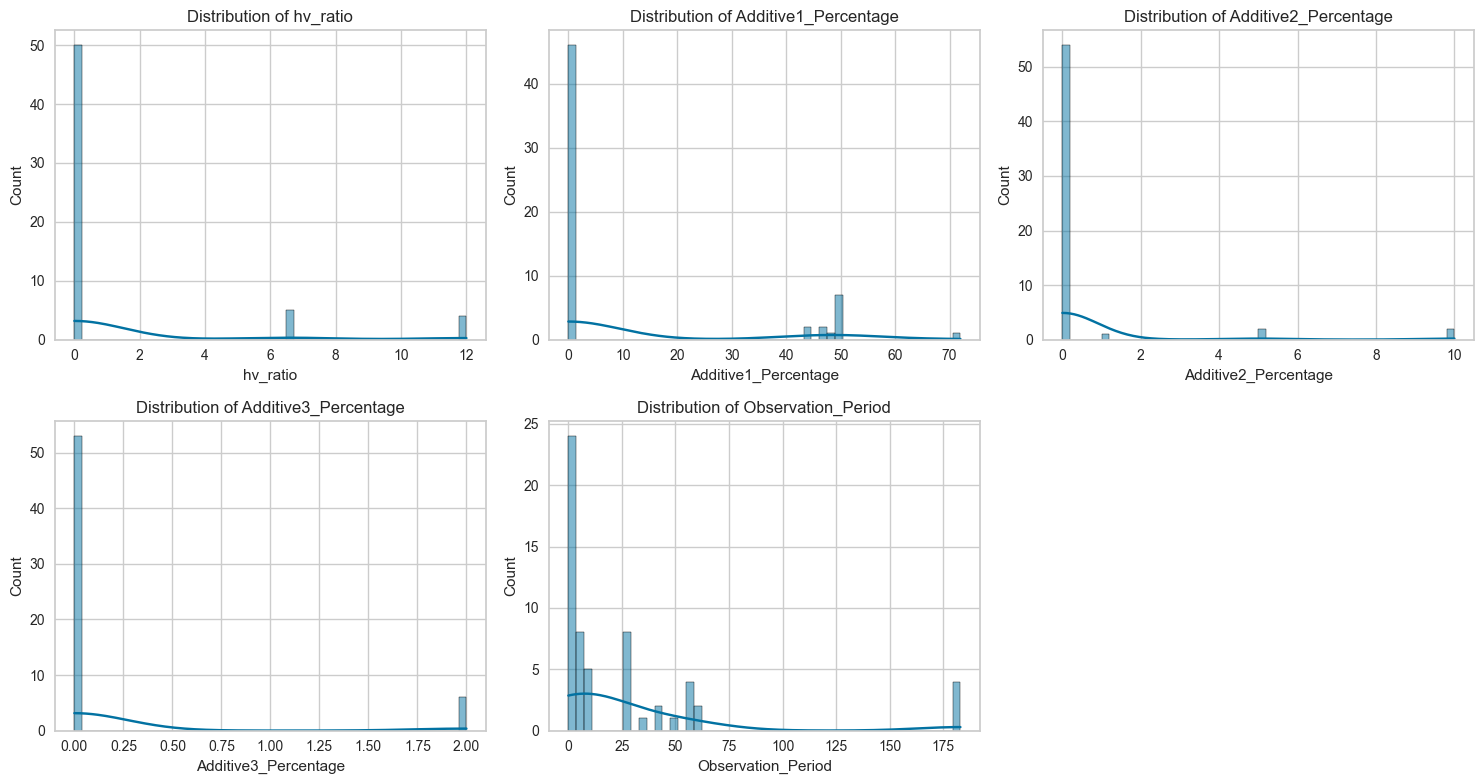

In [172]:
# Plot the distribution of numerical features
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)
plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(X_train[col], kde=True, bins=50)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## Outlier Detection

In [174]:
apply_outlier_detection = False  # Set to False to skip

if apply_outlier_detection:
    data = X_train.select_dtypes(include=[np.number])
    outlier_mask = pd.DataFrame(False, index=X_train.index, columns=data.columns)

    for col in data.columns:
        Q1 = np.percentile(data[col], 25)
        Q3 = np.percentile(data[col], 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_mask[col] = (data[col] < lower) | (data[col] > upper)

    outlier_rows = outlier_mask.any(axis=1)
    X_train_clean = X_train[~outlier_rows]
    y_train_clean = y_train[~outlier_rows]

    print(f"Removed {outlier_rows.sum()} outlier rows. Remaining: {len(X_train_clean)}")
else:
    X_train_clean = X_train.copy()
    y_train_clean = y_train.copy()
    print("Outlier detection skipped.")

Outlier detection skipped.


## Examine Categorical Features

In [176]:
for column in X_train_clean.select_dtypes(include=['object']).columns.tolist():
    print("\n")
    print(X_train[column].value_counts())



Additive1_Use
not_applicable    46
Plasticizer        6
Structural         3
Flexibilizer       3
Polymer_Matrix     1
Name: count, dtype: int64


Additive2_Use
not_applicable         53
Natural_Antioxidant     6
Name: count, dtype: int64


Additive3_Use
not_applicable    53
Chain_Extender     6
Name: count, dtype: int64


Species_Group
Aquatic_Organisms    35
Terrestrial_Plant    24
Name: count, dtype: int64


Exposure_type
Waterborne       29
Soil             23
Orally            4
Dietary           2
Mulch_extract     1
Name: count, dtype: int64


Media_type
Sandy_Soil                                9
Filtered_Seawater                         7
Artificial_Freshwater                     5
Standard_soil_with_5_compost              5
Egg_water                                 4
Agricultural_soil                         4
Diluted_biodegraded_synthetic_seawater    4
Standard_soil_with_10_compost             3
Disinfected_Seawater                      3
Steinberg_medium                  

## Handle Categorical Features

In [178]:
# Group Media type in smaller meaningfull categories
media_merge_map = {
    # Freshwater
    'Artificial_Freshwater': 'Freshwater',
    'Freshwater_simulation': 'Freshwater',
    'Freshwater':            'Freshwater',

    # Seawater
    'Filtered_Seawater':                       'Seawater',
    'Disinfected_Seawater':                    'Seawater',
    'Artificial_Seawater':                     'Seawater',
    'Autoclaved_Seawater':                     'Seawater',
    'Diluted_biodegraded_natural_seawater':    'Seawater',
    'Diluted_biodegraded_synthetic_seawater':  'Seawater',

    # Soil
    'Sandy_Soil':                    'Soil',
    'Agricultural_soil':             'Soil',
    'Standard_soil_with_5_compost':  'Soil',
    'Standard_soil_with_10_compost': 'Soil',
    'Potting_Substrate':             'Soil',

    # Other
    'Egg_water':        'Other',
    'Steinberg_medium': 'Other',
    'MS_plant_culture_medium_ME': 'Other',
}

X_train_clean['Media_type'] = X_train_clean['Media_type'].map(media_merge_map)
X_test['Media_type'] = X_test['Media_type'].map(media_merge_map)
print(X_train_clean['Media_type'].value_counts(normalize=True))
print(X_test['Media_type'].value_counts(normalize=True))

Media_type
Soil          0.389831
Seawater      0.355932
Other         0.135593
Freshwater    0.118644
Name: proportion, dtype: float64
Media_type
Soil          0.357143
Seawater      0.357143
Freshwater    0.142857
Other         0.142857
Name: proportion, dtype: float64


In [179]:
def fit_rare_category_collapser(X, cat_cols, min_freq=0.05, other_label='other'):
    """
    Learns which categories are rare from training data only.

    Parameters
    ----------
    X : pd.DataFrame
    cat_cols : list
    min_freq : float
        Minimum proportion to keep a category.
    other_label : str

    Returns
    -------
    rare_map : dict mapping column -> set of rare categories
    """
    rare_map = {}
    for col in cat_cols:
        freq = X[col].value_counts(normalize=True)
        rare_map[col] = set(freq[freq < min_freq].index)
    return rare_map


def transform_rare_categories(X, rare_map, other_label='other'):
    """
    Applies rare category collapsing learned from training data.

    Parameters
    ----------
    X : pd.DataFrame
    rare_map : dict from fit_rare_category_collapser
    other_label : str

    Returns
    -------
    X_transformed : pd.DataFrame
    """
    X = X.copy()
    for col, rare_cats in rare_map.items():
        X[col] = X[col].replace(rare_cats, other_label)
    return X


def fit_merge_small_other(X, cat_cols, min_count=5, other_label='other'):
    """
    Learns from training data which columns have a small 'other' group
    and which named category to merge it into.

    Parameters
    ----------
    X : pd.DataFrame
    cat_cols : list
    min_count : int
        Minimum absolute count for 'other' to be kept as its own category.
    other_label : str

    Returns
    -------
    merge_map : dict mapping column -> target category to absorb 'other'
                (None if 'other' is large enough or doesn't exist)
    """
    merge_map = {}
    for col in cat_cols:
        if other_label not in X[col].values:
            merge_map[col] = None
            continue
        other_count = (X[col] == other_label).sum()
        if other_count < min_count:
            freq = X[col][X[col] != other_label].value_counts()
            least_frequent = freq.index[-1]
            print(f"[{col}] 'other' has only {other_count} rows → merging into '{least_frequent}'")
            merge_map[col] = least_frequent
        else:
            merge_map[col] = None
    return merge_map


def transform_merge_small_other(X, merge_map, other_label='other'):
    """
    Applies the merging of small 'other' groups learned from training data.

    Parameters
    ----------
    X : pd.DataFrame
    merge_map : dict from fit_merge_small_other
    other_label : str

    Returns
    -------
    X_transformed : pd.DataFrame
    """
    X = X.copy()
    for col, target_cat in merge_map.items():
        if target_cat is not None:
            X[col] = X[col].replace(other_label, target_cat)
    return X



cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Collapse rare categories into 'other' (fit on train only)
rare_map = fit_rare_category_collapser(X_train_clean, cat_cols, min_freq=0.05)
X_train_clean = transform_rare_categories(X_train_clean, rare_map)
X_test_clean = transform_rare_categories(X_test, rare_map)

# Merge small 'other' groups into least frequent named category (fit on train only)
merge_map = fit_merge_small_other(X_train_clean, cat_cols, min_count=5)
X_train_clean = transform_merge_small_other(X_train_clean, merge_map)
X_test_clean = transform_merge_small_other(X_test_clean, merge_map)

# Drop columns with only one category after transformations (fit on train only)
cols_to_drop = [col for col in cat_cols if X_train_clean[col].nunique() <= 1]
X_train_clean = X_train_clean.drop(columns=cols_to_drop)
X_test_clean = X_test_clean.drop(columns=cols_to_drop)
cat_cols = [c for c in cat_cols if c not in cols_to_drop]
print(f"{cols_to_drop} has only 1 category and has been dropped from train set")

[Additive1_Use] 'other' has only 1 rows → merging into 'Flexibilizer'
[Exposure_type] 'other' has only 3 rows → merging into 'Orally'
[] has only 1 category and has been dropped from train set


In [182]:
# Check the new categories
for col in cat_cols:
    print("\n")
    print(X_train_clean[col].value_counts())



Additive1_Use
not_applicable    46
Plasticizer        6
Flexibilizer       4
Structural         3
Name: count, dtype: int64


Additive2_Use
not_applicable         53
Natural_Antioxidant     6
Name: count, dtype: int64


Additive3_Use
not_applicable    53
Chain_Extender     6
Name: count, dtype: int64


Species_Group
Aquatic_Organisms    35
Terrestrial_Plant    24
Name: count, dtype: int64


Exposure_type
Waterborne    29
Soil          23
Orally         7
Name: count, dtype: int64


Media_type
Soil          23
Seawater      21
Other          8
Freshwater     7
Name: count, dtype: int64


Exposure_Regime
Chronic    30
Acute      29
Name: count, dtype: int64


In [186]:
y_train_clean = y_train_clean.loc[X_train_clean.index].reset_index(drop=True)
y_test_clean  = y_test.loc[X_test_clean.index].reset_index(drop=True)

X_train_clean = X_train_clean.reset_index(drop=True)
X_test_clean  = X_test_clean.reset_index(drop=True)

assert len(X_train_clean) == len(y_train_clean)
assert len(X_test_clean)  == len(y_test_clean)
print(f"Train: {len(X_train_clean)} rows | Test: {len(X_test_clean)} rows")

Train: 59 rows | Test: 14 rows


# Feature Selection 

In [190]:
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

features_num = numerical_cols
features_cat = categorical_cols

Numerical features (5):
  - hv_ratio
  - Additive1_Percentage
  - Additive2_Percentage
  - Additive3_Percentage
  - Observation_Period

Categorical features (7):
  - Additive1_Use
  - Additive2_Use
  - Additive3_Use
  - Species_Group
  - Exposure_type
  - Media_type
  - Exposure_Regime


## Mutual Information 

In [193]:
# Check mutual information between features and target  (numerical and categorical features(ordinal encoded))
# Ordinal encode categorical features for mutual information calculation
ordinal_encoder = OrdinalEncoder()
X_train_encoded = X_train_clean.copy()
X_train_encoded[features_cat] = ordinal_encoder.fit_transform(X_train_encoded[features_cat])    
mi_scores = mutual_info_classif(X_train_encoded, y_train_clean, discrete_features=[X_train_encoded.columns.get_loc(c) for c in features_cat], random_state=10)
mi_scores_series = pd.Series(mi_scores, index=X_train_encoded.columns).sort_values(ascending=False)
print("Mutual Information Scores:")
print(mi_scores_series)
# mi_scores_series.to_excel('mi_scores_ecotoxicity.xlsx')

Mutual Information Scores:
Observation_Period      0.167425
Additive1_Use           0.079149
Additive1_Percentage    0.067639
Additive2_Percentage    0.054444
Additive2_Use           0.047873
Additive3_Use           0.047873
Exposure_type           0.039678
Media_type              0.030081
Exposure_Regime         0.013618
Species_Group           0.006250
hv_ratio                0.000000
Additive3_Percentage    0.000000
dtype: float64


## Kendall Correlation (Num vs Num)

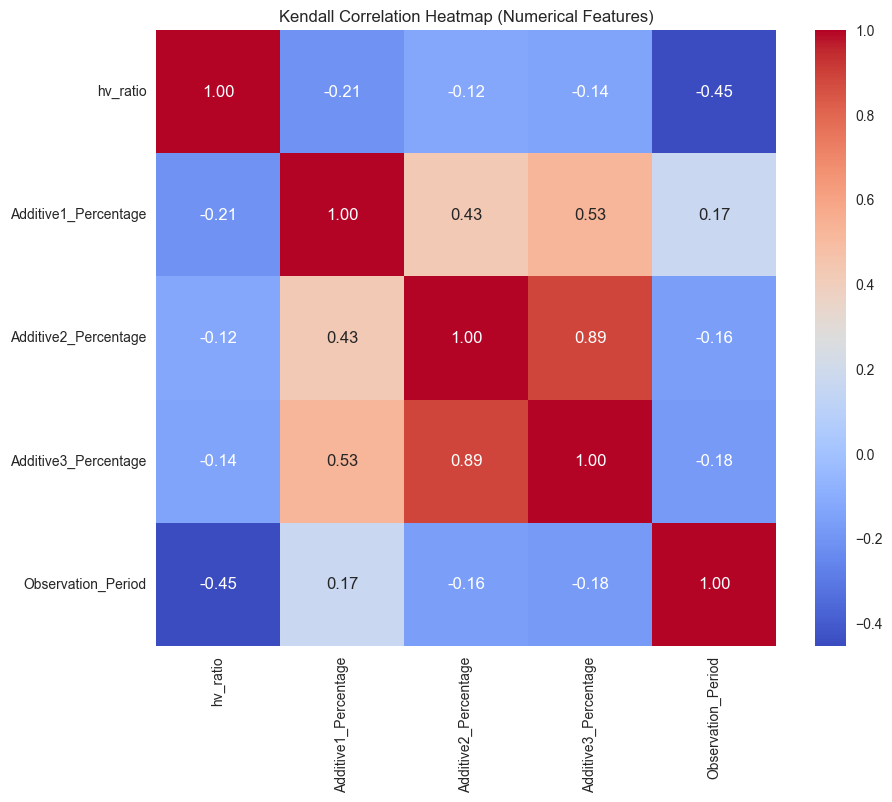

In [196]:
# Use Kendall correlation for numerical features between them
kendall_corr = X_train_clean[numerical_cols].corr(method='kendall')
plt.figure(figsize=(10, 8))
sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Kendall Correlation Heatmap (Numerical Features)')
# plt.savefig('../plots/Kendall Correlation Heatmap - Ecotoxicity Model.png', dpi=600, bbox_inches='tight')

plt.show()

## Cramér's V (Cat vs Cat)

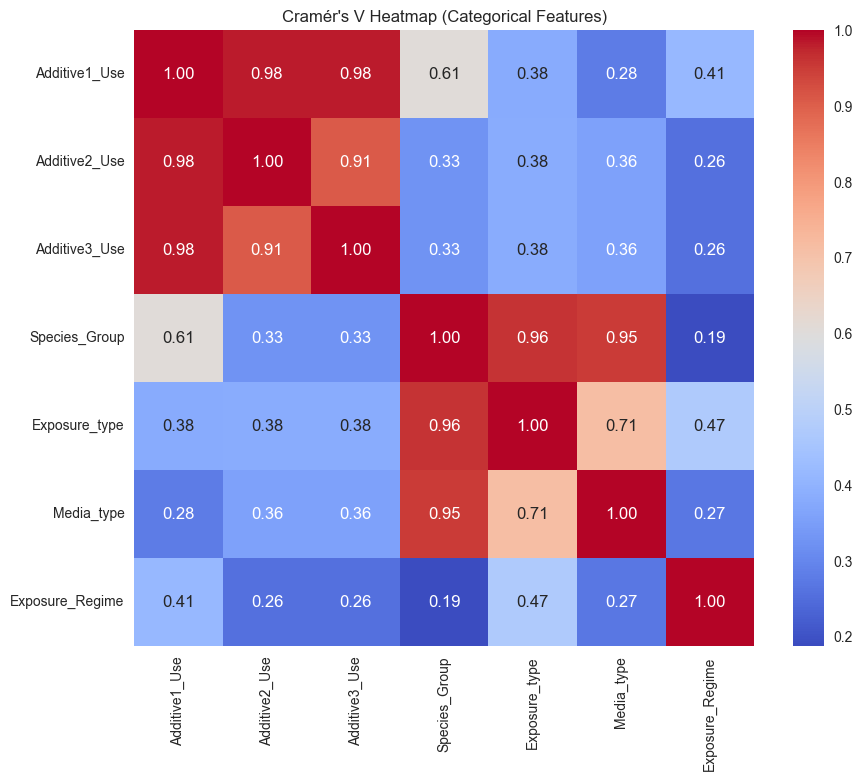

In [198]:
# Use cramer's V for categorical features between them
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))    
cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()
cramers_v_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(X_train_clean[col1], X_train_clean[col2])
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_v_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cramér's V Heatmap (Categorical Features)")
plt.show()

## Drop Unnecessary Features

In [201]:
# feature_to_drop = mi_scores_series.keys()[-1] # get the feature with the lowest MI score
# X_train_clean = X_train_clean.drop(columns=feature_to_drop)
# X_test_clean  = X_test_clean.drop(columns=feature_to_drop)
# print(f"Drop feature: {feature_to_drop}") 

# Machine Learning Algorithm

In [203]:
# Recompute numerical and categorical features 
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

features_num = numerical_cols
features_cat = categorical_cols 

Numerical features (5):
  - hv_ratio
  - Additive1_Percentage
  - Additive2_Percentage
  - Additive3_Percentage
  - Observation_Period

Categorical features (7):
  - Additive1_Use
  - Additive2_Use
  - Additive3_Use
  - Species_Group
  - Exposure_type
  - Media_type
  - Exposure_Regime


In [205]:
# Preprocessing pipeline
def build_preprocessor(features_num, features_cat):
    """
    Returns a fresh, unfitted ColumnTransformer.
    Call this every time you need a new preprocessor instance
    """
    return ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                features_num
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",   
                    sparse_output=False,
                    drop="if_binary"           
                ),
                features_cat
            ),
        ],
        remainder="drop",  # drop any column not explicitly listed
    )

## Applicability Domain

In [210]:
# Preprocessing only for Applicability domain
pre_ad = build_preprocessor(features_num, features_cat)
 
X_train_preprocessed = pre_ad.fit_transform(X_train_clean)
X_test_preprocessed  = pre_ad.transform(X_test_clean)
 
print("\nPreprocessed shapes:")
print(f"  X_train_preprocessed: {X_train_preprocessed.shape}")
print(f"  X_test_preprocessed:  {X_test_preprocessed.shape}")


Preprocessed shapes:
  X_train_preprocessed: (59, 20)
  X_test_preprocessed:  (14, 20)


In [212]:
y_train_clean.value_counts()

Toxicity_Classification
Non_Toxic    38
Toxic        21
Name: count, dtype: int64

## Pycaret's baseline model comparison 

In [215]:
# Built Pycaret's datasets
train_data = X_train_clean.copy()
train_data[target] = y_train_clean.values

test_data_ad = X_test_clean.copy()
test_data_ad[target] = y_test_clean.values

# Pycaret setup
clf = setup(data=train_data,
            test_data=test_data_ad,
            target=target,
            preprocess=True,
            fold=5,
            fold_shuffle=True,
            fold_strategy= RepeatedStratifiedKFold(n_repeats=5, random_state=42),
            index=False, # not treat the index column as a feature
            session_id=42)

,Description,Value
0,Session id,42
1,Target,Toxicity_Classification
2,Target type,Binary
3,Target mapping,"Non_Toxic: 0, Toxic: 1"
4,Original data shape,"(73, 13)"
5,Transformed data shape,"(73, 21)"
6,Transformed train set shape,"(59, 21)"
7,Transformed test set shape,"(14, 21)"
8,Numeric features,5
9,Categorical features,7


In [217]:
# Baseline comparison (no imbalance)
baseline = compare_models(sort='mcc', n_select=1)
baseline_results = pull()
print("\n=== BASELINE RANKING (read top 3 from here) ===")
print(baseline_results[['Model', 'MCC', 'AUC', 'Recall', 'F1']].head(3).to_string())

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7091,0.7675,0.7091,0.7399,0.6997,0.3596,0.3897,0.0916
dt,Decision Tree Classifier,0.7082,0.6812,0.7082,0.7235,0.6989,0.3460,0.3659,0.0580
rf,Random Forest Classifier,0.6912,0.7480,0.6912,0.7155,0.6856,0.3287,0.3494,0.1264
et,Extra Trees Classifier,0.6945,0.7121,0.6945,0.7084,0.6866,0.3209,0.3382,0.1208
ada,Ada Boost Classifier,0.6691,0.7291,0.6691,0.6906,0.6621,0.2734,0.2925,0.0888
knn,K Neighbors Classifier,0.6521,0.6906,0.6521,0.6865,0.6454,0.2680,0.2880,0.0756
nb,Naive Bayes,0.5188,0.6492,0.5188,0.7238,0.4801,0.1782,0.2737,0.0584
lda,Linear Discriminant Analysis,0.6073,0.6370,0.6073,0.6247,0.5951,0.1421,0.1584,0.0604
ridge,Ridge Classifier,0.6145,0.6346,0.6145,0.6137,0.5972,0.1316,0.1398,0.0556
lr,Logistic Regression,0.6039,0.6235,0.6039,0.6009,0.5852,0.1036,0.1117,0.2804



=== BASELINE RANKING (read top 3 from here) ===
                            Model     MCC     AUC  Recall      F1
gbc  Gradient Boosting Classifier  0.3897  0.7675  0.7091  0.6997
dt       Decision Tree Classifier  0.3659  0.6812  0.7082  0.6989
rf       Random Forest Classifier  0.3494  0.7480  0.6912  0.6856


In [219]:
# Optimize the best model's hyperparameters using Optuna with early stopping
tuned_model = tune_model(baseline,
                         optimize='mcc',
                         search_library='optuna', 
                         n_iter=50,
                         )
# Check the best hyperparameters found
print("Best hyperparameters:", tuned_model.get_params())

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6667,0.5625,0.6667,0.6667,0.6667,0.2500,0.2500
1,0.5833,0.5781,0.5833,0.6095,0.5926,0.1176,0.1195
2,0.5000,0.7188,0.5000,0.6250,0.5000,0.1000,0.1250
3,0.6667,0.8000,0.6667,0.7879,0.5926,0.2258,0.3568
4,0.7273,0.8571,0.7273,0.8091,0.6695,0.2979,0.4183
5,0.6667,0.6875,0.6667,0.6667,0.6667,0.2500,0.2500
6,0.6667,0.6875,0.6667,0.6667,0.6667,0.2500,0.2500
7,0.8333,0.9375,0.8333,0.8333,0.8333,0.6250,0.6250
8,0.7500,0.7429,0.7500,0.7500,0.7444,0.4706,0.4781


Best hyperparameters: {'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.4044750534319239, 'loss': 'log_loss', 'max_depth': 9, 'max_features': 0.8599560454772718, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.000725849452238992, 'min_samples_leaf': 3, 'min_samples_split': 6, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 157, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 0.7204343169822136, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


In [221]:
predict_model(tuned_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.8571,0.9444,0.8571,0.8571,0.8571,0.6889,0.6889


,hv_ratio,Additive1_Percentage,Additive2_Percentage,Additive3_Percentage,Observation_Period,Additive1_Use,Additive2_Use,Additive3_Use,Species_Group,Exposure_type,Media_type,Exposure_Regime,Toxicity_Classification,prediction_label,prediction_score
59,0.0,48.5,1.0,2.0,3.0,Plasticizer,Natural_Antioxidant,Chain_Extender,Terrestrial_Plant,Soil,Soil,Acute,Non_Toxic,Non_Toxic,1.0000
60,0.0,50.0,0.0,0.0,28.0,Structural,not_applicable,not_applicable,Terrestrial_Plant,Soil,Soil,Chronic,Non_Toxic,Non_Toxic,0.9997
61,0.0,0.0,0.0,0.0,183.0,not_applicable,not_applicable,not_applicable,Terrestrial_Plant,Soil,Soil,Chronic,Non_Toxic,Non_Toxic,1.0000
62,0.0,0.0,0.0,0.0,4.0,not_applicable,not_applicable,not_applicable,Aquatic_Organisms,Waterborne,Seawater,Acute,Non_Toxic,Non_Toxic,0.9983
63,0.0,0.0,0.0,0.0,3.0,not_applicable,not_applicable,not_applicable,Aquatic_Organisms,Waterborne,Freshwater,Acute,Toxic,Toxic,0.9783
64,0.0,72.0,0.0,0.0,21.0,Flexibilizer,not_applicable,not_applicable,Terrestrial_Plant,Orally,Other,Chronic,Toxic,Toxic,1.0000
65,0.0,0.0,0.0,0.0,4.0,not_applicable,not_applicable,not_applicable,Aquatic_Organisms,Waterborne,Seawater,Acute,Non_Toxic,Non_Toxic,0.9983
66,0.0,0.0,0.0,0.0,2.0,not_applicable,not_applicable,not_applicable,Aquatic_Organisms,Waterborne,Seawater,Acute,Toxic,Toxic,0.9999
67,0.0,0.0,0.0,0.0,60.0,not_applicable,not_applicable,not_applicable,Aquatic_Organisms,Orally,Seawater,Chronic,Toxic,Non_Toxic,0.6239
68,0.0,50.0,0.0,0.0,183.0,Flexibilizer,not_applicable,not_applicable,Terrestrial_Plant,Soil,Soil,Chronic,Non_Toxic,Non_Toxic,1.0000


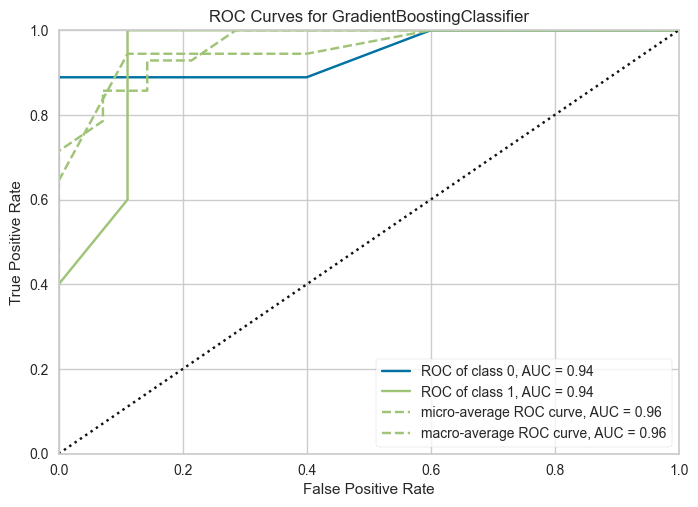

In [223]:
plot_model(tuned_model)

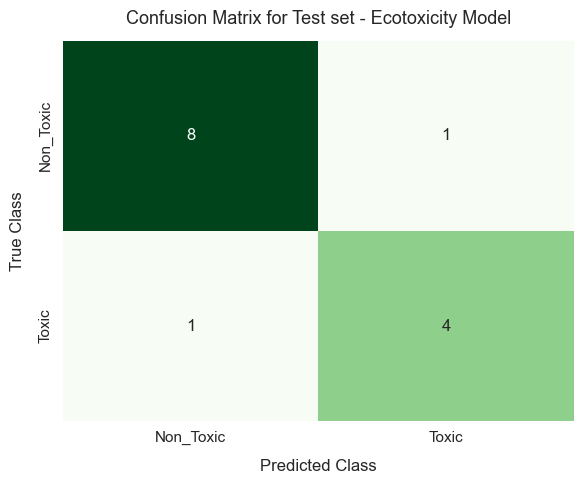

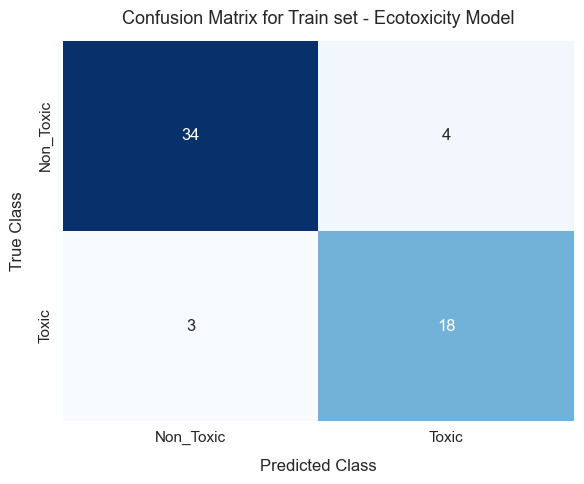

In [225]:
# Plot confusion matrix for train and test set based on the tuned model predictions
def plot_confusion_matrix(cm, title, color):
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap=color, cbar=False)
    
    classes = sorted(y_train_clean.unique())
    ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticklabels(classes, fontsize=11)    
    # Remove tick marks and spines
    ax.tick_params(which='both', bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xlabel('Predicted Class', fontsize=12, labelpad=10)
    ax.set_ylabel('True Class', fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    # plt.show()
    plt.show() 
    
predictions = predict_model(tuned_model, data=X_test_clean)

X_test_pred = predictions['prediction_label']  # predicted classes
cm_test = confusion_matrix(y_test_clean, X_test_pred)
plot_confusion_matrix(cm_test, 'Confusion Matrix for Test set - Ecotoxicity Model', 'Greens')

# Same for train
train_predictions = predict_model(tuned_model, data=X_train_clean)
X_train_pred = train_predictions['prediction_label']
cm_train = confusion_matrix(y_train_clean, X_train_pred)
plot_confusion_matrix(cm_train, 'Confusion Matrix for Train set - Ecotoxicity Model', 'Blues')

In [227]:
print(X_train_clean.columns.tolist())

['hv_ratio', 'Additive1_Percentage', 'Additive2_Percentage', 'Additive3_Percentage', 'Observation_Period', 'Additive1_Use', 'Additive2_Use', 'Additive3_Use', 'Species_Group', 'Exposure_type', 'Media_type', 'Exposure_Regime']


In [229]:
print(type(tuned_model))

<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>


In [231]:
# train_data here must be the FULL version (with cell_line, exposure_type, shape, polymer_percentage still included)
clf_setup = setup(data=train_data, target=target, session_id=1231)

X_train_transformed = get_config('X_train_transformed')
y_train_transformed = get_config('y_train_transformed')
X_test_transformed = get_config('X_test_transformed')
y_test_transformed = get_config('y_test_transformed')

print(sorted(X_train_transformed.columns.tolist()) == sorted(tuned_model.feature_names_in_.tolist()))  # sanity check — should be True

,Description,Value
0,Session id,1231
1,Target,Toxicity_Classification
2,Target type,Binary
3,Target mapping,"Non_Toxic: 0, Toxic: 1"
4,Original data shape,"(59, 13)"
5,Transformed data shape,"(59, 21)"
6,Transformed train set shape,"(41, 21)"
7,Transformed test set shape,"(18, 21)"
8,Numeric features,5
9,Categorical features,7


True


In [232]:
X_train_transformed = X_train_transformed[tuned_model.feature_names_in_]
X_test_transformed = X_test_transformed[tuned_model.feature_names_in_]

train_pred = tuned_model.predict(X_train_transformed)
test_pred = tuned_model.predict(X_test_transformed)

train_bal_acc = balanced_accuracy_score(y_train_transformed, train_pred)
train_macro_f1 = f1_score(y_train_transformed, train_pred, average='macro')
test_bal_acc = balanced_accuracy_score(y_test_transformed, test_pred)
test_macro_f1 = f1_score(y_test_transformed, test_pred, average='macro')

print(f"Train | Balanced Accuracy: {train_bal_acc:.4f} | macro-F1: {train_macro_f1:.4f}")
print(f"Test  | Balanced Accuracy: {test_bal_acc:.4f} | macro-F1: {test_macro_f1:.4f}")

Train | Balanced Accuracy: 0.8756 | macro-F1: 0.8703
Test  | Balanced Accuracy: 0.8750 | macro-F1: 0.8750


In [239]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=1231)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1231)

cv_bal_acc_repeated = cross_val_score(tuned_model, X_train_transformed, y_train_transformed, cv=skf, scoring='balanced_accuracy')
cv_macro_f1_repeated = cross_val_score(tuned_model, X_train_transformed, y_train_transformed, cv=skf, scoring='f1_macro')

print(f"Repeated CV (5-fold × 20) | Balanced Accuracy: {cv_bal_acc_repeated.mean():.4f} ± {cv_bal_acc_repeated.std():.4f}")
print(f"Repeated CV (5-fold × 20) | macro-F1: {cv_macro_f1_repeated.mean():.4f} ± {cv_macro_f1_repeated.std():.4f}")

Repeated CV (5-fold × 20) | Balanced Accuracy: 0.6500 ± 0.1814
Repeated CV (5-fold × 20) | macro-F1: 0.6444 ± 0.1744


## save model for Jaqpot

In [105]:
JAQPOT_COMPATIBLE_CLASSIFIERS = [
    'AdaBoostClassifier',
    'BaggingClassifier',
    'BernoulliNB',
    'CalibratedClassifierCV',
    'CategoricalNB',
    'ComplementNB',
    'DecisionTreeClassifier',
    'ExtraTreeClassifier',
    'ExtraTreesClassifier',
    'GaussianNB',
    'GaussianProcessClassifier',
    'GradientBoostingClassifier',
    'HistGradientBoostingClassifier',
    'KNeighborsClassifier',
    'LinearSVC',
    'LogisticRegression',       
    'MLPClassifier',
    'MultinomialNB',
    'OneVsOneClassifier',
    'OneVsRestClassifier',
    'QuadraticDiscriminantAnalysis',
    'RadiusNeighborsClassifier',
    'RandomForestClassifier',
    'SGDClassifier',
    'SVC',
    'StackingClassifier',
    'VotingClassifier',
    'RidgeClassifier',           
    'LinearDiscriminantAnalysis', 
]

# Tree-based models: capture non-linear relationships in small heterogeneous
# datasets and support exact SHAP computation via TreeExplainer
TREE_BASED_CLASSIFIERS = {
    'DecisionTreeClassifier',
    'ExtraTreeClassifier',
    'ExtraTreesClassifier',
    'GradientBoostingClassifier',
    'HistGradientBoostingClassifier',
    'RandomForestClassifier',
}

In [107]:
best_results = compare_models(sort='mcc', n_select=5)
chosen_model = None

for m in best_results:
    if type(m).__name__ in JAQPOT_COMPATIBLE_CLASSIFIERS and type(m).__name__ in TREE_BASED_CLASSIFIERS:
        chosen_model = m
        break
if chosen_model is None:
    for m in best_results:
        if type(m).__name__ in JAQPOT_COMPATIBLE_CLASSIFIERS:
            chosen_model = m
            break

tuned_chosen = tune_model(chosen_model, optimize='mcc', search_library='optuna', n_iter=10)
final_model = type(tuned_chosen)(**tuned_chosen.get_params())

import joblib
joblib.dump(final_model, 'final_model_eco.pkl')
print("Model saved for jaqpot notebook")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.7350,0.6917,0.7350,0.8225,0.7367,0.4533,0.5053,0.2330
lda,Linear Discriminant Analysis,0.6600,0.6583,0.6600,0.7558,0.6600,0.3033,0.3631,0.2490
lr,Logistic Regression,0.6600,0.7000,0.6600,0.7517,0.6567,0.2700,0.3297,2.4600
knn,K Neighbors Classifier,0.6650,0.7042,0.6650,0.7308,0.6633,0.2879,0.3232,1.0730
rf,Random Forest Classifier,0.6850,0.7750,0.6850,0.6829,0.6576,0.2833,0.3143,0.5230
et,Extra Trees Classifier,0.6600,0.7667,0.6600,0.6788,0.6310,0.2533,0.2899,0.4570
dt,Decision Tree Classifier,0.6400,0.6125,0.6400,0.6517,0.5986,0.1713,0.2143,0.2700
ada,Ada Boost Classifier,0.6350,0.7500,0.6350,0.6329,0.6076,0.1500,0.1809,0.4400
qda,Quadratic Discriminant Analysis,0.4650,0.5667,0.4650,0.4139,0.3862,0.1200,0.1488,0.2540
gbc,Gradient Boosting Classifier,0.6100,0.7917,0.6100,0.5996,0.5843,0.1000,0.1232,0.3700


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6000,0.5000,0.6000,0.6000,0.6000,0.1667,0.1667
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,0.7500,0.8333,0.7500,0.8750,0.7667,0.5000,0.5774
3,0.7500,0.6667,0.7500,0.8750,0.7667,0.5000,0.5774
4,0.5000,0.3333,0.5000,0.5000,0.5000,-0.3333,-0.3333
5,0.7500,1.0000,0.7500,0.8750,0.7667,0.5000,0.5774
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,0.5000,0.5000,0.5000,0.2500,0.3333,0.0000,0.0000
8,0.5000,0.5000,0.5000,0.5000,0.5000,0.0000,0.0000


Model saved for jaqpot notebook


## SHAP plot

In [241]:
X_train = X_train_clean.copy()

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=None)
ohe.fit(X_train[categorical_cols])

# Transform
X_train_ohe = ohe.transform(X_train[categorical_cols])
X_test_ohe = ohe.transform(X_test[categorical_cols])

# Convert to DataFrame with proper column names
ohe_columns = ohe.get_feature_names_out(categorical_cols)
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_columns, index=X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=ohe_columns, index=X_test.index)

In [243]:
# combine
X_train_final = pd.concat([X_train.drop(columns=categorical_cols), X_train_ohe_df], axis=1)
X_test_final = pd.concat([X_test.drop(columns=categorical_cols), X_test_ohe_df], axis=1)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape: {X_test_final.shape}")

X_train_final shape: (59, 24)
X_test_final shape: (14, 24)


In [245]:
explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_test_final)     # array shape: (n_samples, n_features)
base_value = explainer.expected_value

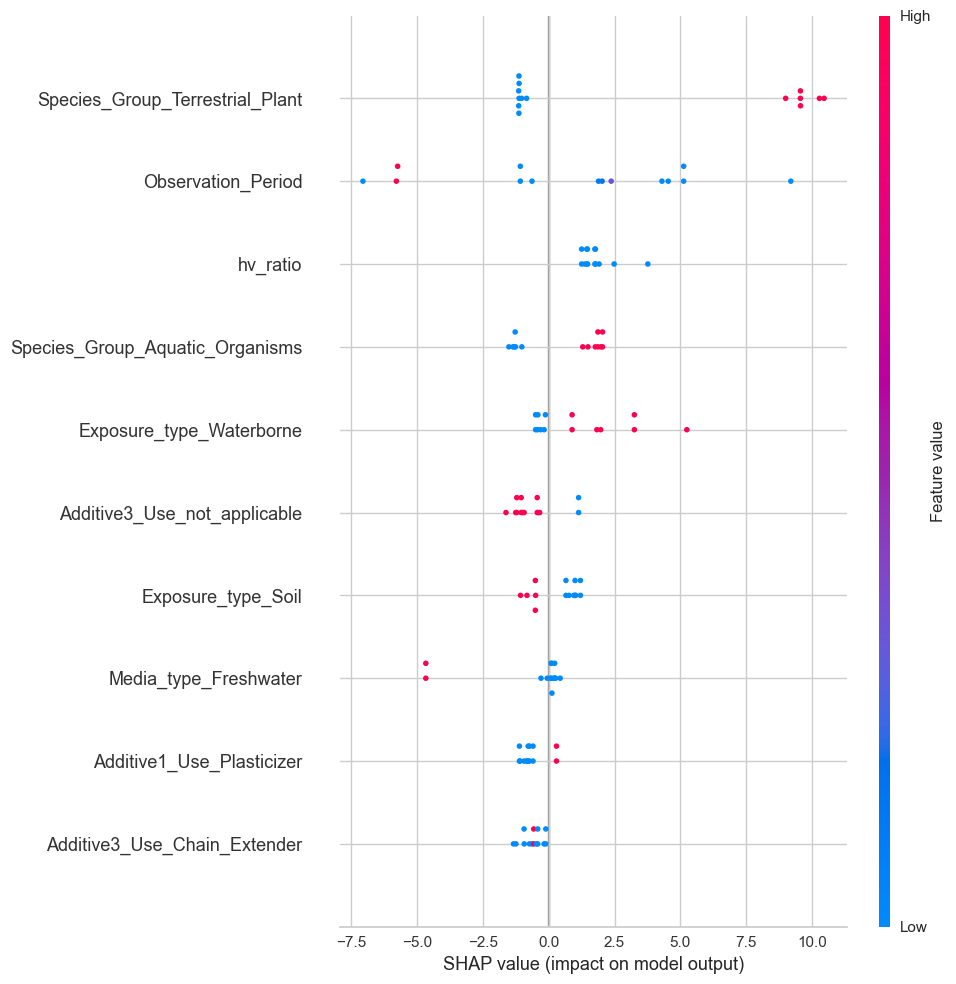

In [247]:
shap.summary_plot(
    shap_values,
    X_test_final,
    max_display=10,        # <-- top 10 features only
    show=False,
    plot_size=(10, 10)
)
plt.tight_layout()
plt.savefig("ecotoxicity_toxic_shap.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

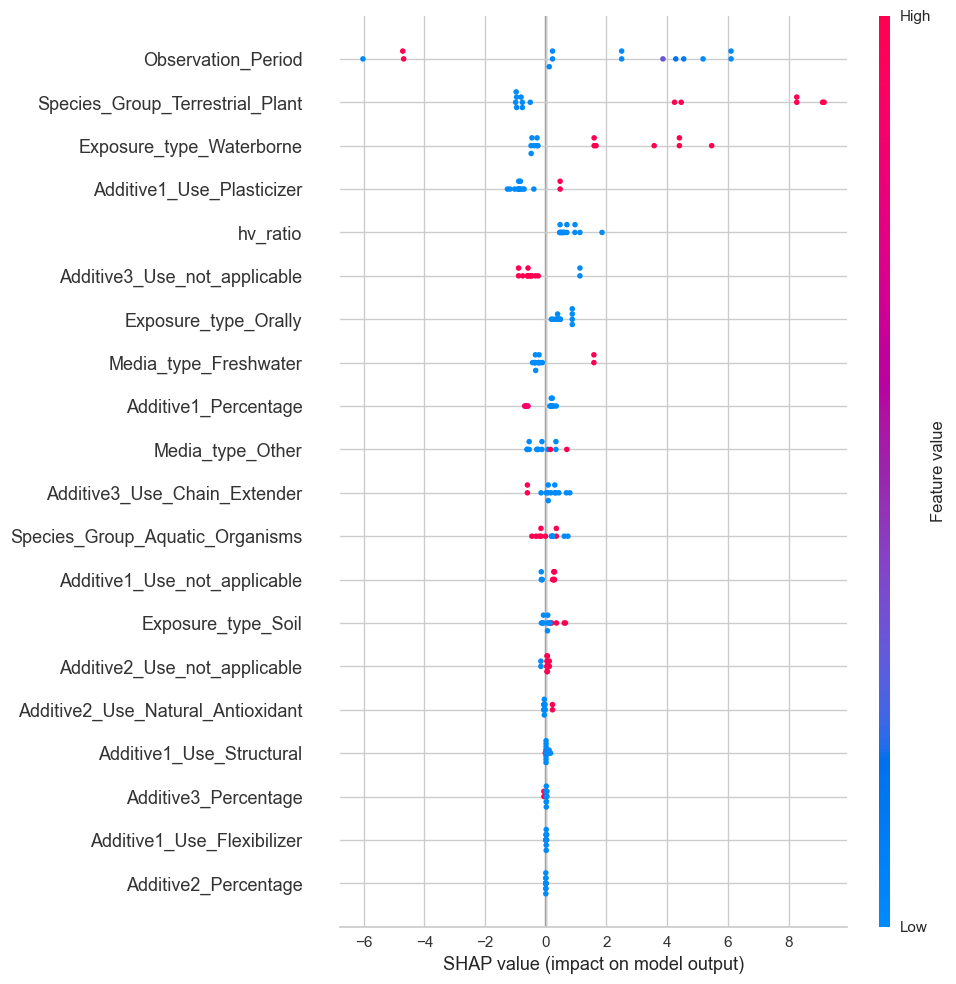

In [129]:
shap.summary_plot(
    shap_values,
    X_test_final,
#    max_display=10,        # <-- top 10 features only
    show=False,
    plot_size=(10, 10)
)
plt.tight_layout()
# plt.savefig("ecotoxicity_toxic_shap.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.show()

# Get Sample Rows for Final Dataset used for Training

In [94]:
sample_df = X_train_clean.copy()
sample_df[target] = y_train_clean
sample_df_fnl = sample_df.sample(20)
print(sample_df_fnl)
sample_df_fnl.to_excel('sample_20_ecotoxicity.xlsx', index=False)

    hv_ratio  Additive1_Percentage  Additive2_Percentage  \
7        0.0                   0.0                   0.0   
55       0.0                  50.0                   0.0   
3        0.0                  50.0                   0.0   
41       0.0                   0.0                   0.0   
29       0.0                  50.0                   0.0   
4        0.0                   0.0                   0.0   
42       0.0                   0.0                   0.0   
0        0.0                  46.5                   5.0   
26       0.0                   0.0                   0.0   
12       0.0                   0.0                   0.0   
37       0.0                   0.0                   0.0   
27      12.0                   0.0                   0.0   
23       6.5                   0.0                   0.0   
30       0.0                   0.0                   0.0   
22       0.0                   0.0                   0.0   
25      12.0                   0.0      

# Final Train and Test Sets

In [96]:
Train_df_fnl = X_train_clean.copy()
Train_df_fnl[target] = y_train_clean
print(Train_df_fnl.sample(20))
Train_df_fnl.to_excel('final_train_set_ecotoxicity.xlsx', index=False)

    hv_ratio  Additive1_Percentage  Additive2_Percentage  \
38       6.5                   0.0                   0.0   
50       0.0                   0.0                   0.0   
2        0.0                   0.0                   0.0   
29       0.0                  50.0                   0.0   
40       0.0                   0.0                   0.0   
56       0.0                   0.0                   0.0   
1        6.5                   0.0                   0.0   
49       0.0                   0.0                   0.0   
47       0.0                   0.0                   0.0   
37       0.0                   0.0                   0.0   
21       0.0                   0.0                   0.0   
41       0.0                   0.0                   0.0   
8        0.0                   0.0                   0.0   
11       0.0                  48.5                   1.0   
30       0.0                   0.0                   0.0   
26       0.0                   0.0      

In [102]:
Test_df_fnl = X_test_clean.copy()
Test_df_fnl[target] = y_test_clean
print(Test_df_fnl.sample(10))
Test_df_fnl.to_excel('final_test_set_ecotoxicity.xlsx', index=False)

    hv_ratio  Additive1_Percentage  Additive2_Percentage  \
11       0.0                   0.0                   0.0   
8        0.0                   0.0                   0.0   
13       0.0                   0.0                   0.0   
10       0.0                   0.0                   0.0   
6        0.0                   0.0                   0.0   
4        0.0                   0.0                   0.0   
5        0.0                  72.0                   0.0   
0        0.0                  48.5                   1.0   
3        0.0                   0.0                   0.0   
9        0.0                  50.0                   0.0   

    Additive3_Percentage  Observation_Period   Additive1_Use  \
11                   0.0                 1.0  not_applicable   
8                    0.0                60.0  not_applicable   
13                   0.0                 3.0  not_applicable   
10                   0.0                 4.0  not_applicable   
6                  

## Reduced model

In [132]:
from pycaret.classification import setup

cols_to_drop = ['Additive3_Percentage', 'Additive3_Use', 'hv_ratio', 'Species_Group']
df_test = Train_df_fnl.drop(columns=cols_to_drop)

clf_setup = setup(
    data=df_test,          # your training dataframe
    target='Toxicity_Classification',     # your target column
    session_id=1231,       # match jaqpot_model.random_seed for reproducibility
)

,Description,Value
0,Session id,1231
1,Target,Toxicity_Classification
2,Target type,Binary
3,Target mapping,"Non_Toxic: 0, Toxic: 1"
4,Original data shape,"(59, 9)"
5,Transformed data shape,"(59, 17)"
6,Transformed train set shape,"(41, 17)"
7,Transformed test set shape,"(18, 17)"
8,Numeric features,3
9,Categorical features,5


In [134]:
JAQPOT_COMPATIBLE_CLASSIFIERS = [
    'AdaBoostClassifier',
    'BaggingClassifier',
    'BernoulliNB',
    'CalibratedClassifierCV',
    'CategoricalNB',
    'ComplementNB',
    'DecisionTreeClassifier',
    'ExtraTreeClassifier',
    'ExtraTreesClassifier',
    'GaussianNB',
    'GaussianProcessClassifier',
    'GradientBoostingClassifier',
    'HistGradientBoostingClassifier',
    'KNeighborsClassifier',
    'LinearSVC',
    'LogisticRegression',       
    'MLPClassifier',
    'MultinomialNB',
    'OneVsOneClassifier',
    'OneVsRestClassifier',
    'QuadraticDiscriminantAnalysis',
    'RadiusNeighborsClassifier',
    'RandomForestClassifier',
    'SGDClassifier',
    'SVC',
    'StackingClassifier',
    'VotingClassifier',
    'RidgeClassifier',           
    'LinearDiscriminantAnalysis', 
]

# Tree-based models: capture non-linear relationships in small heterogeneous
# datasets and support exact SHAP computation via TreeExplainer
TREE_BASED_CLASSIFIERS = {
    'DecisionTreeClassifier',
    'ExtraTreeClassifier',
    'ExtraTreesClassifier',
    'GradientBoostingClassifier',
    'HistGradientBoostingClassifier',
    'RandomForestClassifier',
}

In [136]:
best_results = compare_models(sort='mcc', n_select=5)
chosen_model = None

for m in best_results:
    if type(m).__name__ in JAQPOT_COMPATIBLE_CLASSIFIERS and type(m).__name__ in TREE_BASED_CLASSIFIERS:
        chosen_model = m
        break
if chosen_model is None:
    for m in best_results:
        if type(m).__name__ in JAQPOT_COMPATIBLE_CLASSIFIERS:
            chosen_model = m
            break

tuned_chosen = tune_model(chosen_model, optimize='mcc', search_library='optuna', n_iter=10)
final_model = type(tuned_chosen)(**tuned_chosen.get_params())

import joblib
joblib.dump(final_model, 'final_model_eco_red.pkl')
print("Model saved for jaqpot notebook")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.7100,0.6917,0.7100,0.8058,0.7100,0.4033,0.4631,0.0430
lda,Linear Discriminant Analysis,0.6850,0.6833,0.6850,0.7725,0.6867,0.3533,0.4053,0.0410
lr,Logistic Regression,0.6600,0.7250,0.6600,0.7517,0.6567,0.2700,0.3297,0.8860
knn,K Neighbors Classifier,0.6650,0.7042,0.6650,0.7308,0.6633,0.2879,0.3232,0.4860
rf,Random Forest Classifier,0.6600,0.8750,0.6600,0.6704,0.6343,0.2333,0.2720,0.1070
qda,Quadratic Discriminant Analysis,0.6350,0.6167,0.6350,0.5446,0.5452,0.2286,0.2563,0.0430
et,Extra Trees Classifier,0.6350,0.8167,0.6350,0.6662,0.6076,0.2033,0.2476,0.1000
gbc,Gradient Boosting Classifier,0.6600,0.7917,0.6600,0.6662,0.6310,0.2000,0.2387,0.0700
ada,Ada Boost Classifier,0.6350,0.7667,0.6350,0.6329,0.6076,0.1500,0.1809,0.0700
nb,Naive Bayes,0.4850,0.7167,0.4850,0.4738,0.4167,0.1152,0.1563,0.0440


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6000,0.5000,0.6000,0.6000,0.6000,0.1667,0.1667
1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,0.7500,0.8333,0.7500,0.8750,0.7667,0.5000,0.5774
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.5000,0.6667,0.5000,0.5000,0.5000,-0.3333,-0.3333
5,0.7500,1.0000,0.7500,0.8750,0.7667,0.5000,0.5774
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,0.5000,1.0000,0.5000,0.2500,0.3333,0.0000,0.0000
8,0.7500,0.7500,0.7500,0.8333,0.7333,0.5000,0.5774


Model saved for jaqpot notebook
